# Análise Exploratória do Brasileirão

Bem-vindo à exploração de dados do desafio FBref! Neste notebook, vamos investigar:
1. Qual o jogador com o melhor **Gols por 90 minutos**?
2. Qual equipe **mais cede gols** aos adversários?

Vamos usar a base analítica gerada em `parquet` para tirar proveito dos MultiIndex do Pandas nativamente.

In [1]:
import pandas as pd
import pyarrow.parquet as pq

# Configurar o pandas para mostrar todas as colunas se necessário
pd.set_option('display.max_columns', None)

## 1. Melhor Gols por 90 minutos

In [2]:
# Carregar estatísticas de jogadores do Parquet
df_players = pd.read_parquet('../data/parquet/player_stats.parquet')

# Inspecionar o formato MultiIndex das colunas
display(df_players.head(3))

nation    pos age  born  \
                                                                          
league      season team             player                                
BRA-Serie A 2526   Atlético Mineiro Alan Franco    ECU     MF  26  1998   
                                    Alexsander     BRA     MF  21  2003   
                                    Bernard        BRA  MF,FW  32  1992   

                                                Playing Time               \
                                                          MP Starts   Min   
league      season team             player                                  
BRA-Serie A 2526   Atlético Mineiro Alan Franco           30     30  2628   
                                    Alexsander            14      8   828   
                                    Bernard               30     12  1210   

                                                      Performance          \
                                                  90s         Gls Ast G+A   
league      season team             player                                  
BRA-Serie A 2526   Atlético Mineiro Alan Franco  29.2           1   0   1   
                                    Alexsander    9.2           1   0   1   
                                    Bernard      13.4           1   1   2   

                                                                         \
                                                G-PK PK PKatt CrdY CrdR   
league      season team             player                                
BRA-Serie A 2526   Atlético Mineiro Alan Franco    1  0     0    4    0   
                                    Alexsander     1  0     0    3    0   
                                    Bernard        1  0     0    4    0   

                                                Per 90 Minutes              \
                                                           Gls   Ast   G+A   
league      season team             player                                   
BRA-Serie A 2526   Atlético Mineiro Alan Franco           0.03  0.00  0.03   
                                    Alexsander            0.11  0.00  0.11   
                                    Bernard               0.07  0.07  0.15   

                                                              
                                                 G-PK G+A-PK  
league      season team             player                    
BRA-Serie A 2526   Atlético Mineiro Alan Franco  0.03   0.03  
                                    Alexsander   0.11   0.11  
                                    Bernard      0.07   0.15

In [3]:
# 1. Filtrar jogadores que atuaram no mínimo 500 minutos (para evitar distorções de amostras pequenas)
min_minutes = 500

# Atenção: O soccerdata coloca league, season, team, player como índices, vamos resetar o index para ficar mais fácil:
df_players_flat = df_players.reset_index()

# Vamos checar as novas colunas
display(df_players_flat.head(1))

league season              team       player nation pos age  born  \
                                                                            
0  BRA-Serie A   2526  Atlético Mineiro  Alan Franco    ECU  MF  26  1998   

  Playing Time                    Performance                                  \
            MP Starts   Min   90s         Gls Ast G+A G-PK PK PKatt CrdY CrdR   
0           30     30  2628  29.2           1   0   1    1  0     0    4    0   

  Per 90 Minutes                          
             Gls  Ast   G+A  G-PK G+A-PK  
0           0.03  0.0  0.03  0.03   0.03

In [4]:
# Definindo o mapeamento exato das colunas a partir do MultiIndex
col_player = ('player', '')
col_team = ('team', '')
col_minutes = ('Playing Time', 'Min')
col_xg90 = ('Per 90 Minutes', 'Gls') # Em 2026 a FBref pode não disponibilizar xG na base gratuita padrão do Brasileirão

# Filtro para jogar os anômalos fora (> 500 minutos)
df_filtered = df_players_flat[df_players_flat[col_minutes] > min_minutes]

# Ordenando do maior para o menor Gols/90
top_xg = df_filtered.sort_values(by=col_xg90, ascending=False)

# Exibindo o Top 10
top_xg[[col_player, col_team, col_minutes, col_xg90]].head(10)

,player,team,Playing Time,Per 90 Minutes
,,,Min,Gls
339,Carlos Vinícius,Grêmio,942,1.15
246,Pedro,Flamengo,1047,1.03
186,Kaio Jorge,Cruzeiro,2588,0.73
289,Adam Bareiro,Fortaleza,886,0.71
225,Giorgian de Arrascaeta,Flamengo,2350,0.69
526,Vitor Roque,Palmeiras,2117,0.68
546,Isidro Pitta,RB Bragantino,1093,0.58
336,Andre Martins,Grêmio,793,0.57
400,Ricardo Mathias,Internacional,809,0.56


## 2. Análise Defensiva de Equipes

Para isso, vamos usar o arquivo `schedule.parquet` para calcular quantos gols cada equipe sofreu, já que algumas bases do FBref podem não entregar métricas 'Against' por padrão dependendo da liga e ano.

In [5]:
df_schedule = pd.read_parquet('../data/parquet/schedule.parquet')
df_schedule = df_schedule.dropna(subset=['score'])

# O placar (score) tem o formato '2–1' (onde o primeiro é o mandante)
df_schedule[['home_goals', 'away_goals']] = df_schedule['score'].str.split('–', expand=True).astype(float)

# Calculando gols sofridos como Mandante
home_defense = df_schedule.groupby('home_team')['away_goals'].sum().reset_index()
home_defense.columns = ['team', 'goals_conceded']

# Calculando gols sofridos como Visitante
away_defense = df_schedule.groupby('away_team')['home_goals'].sum().reset_index()
away_defense.columns = ['team', 'goals_conceded']

# Somando os dois para ter o Total de Gols Sofridos
df_defense = pd.concat([home_defense, away_defense]).groupby('team').sum().reset_index()
df_defense = df_defense.sort_values(by='goals_conceded', ascending=False)

display(df_defense.head(10))

,team,goals_conceded
16,Sport Recife,75.0
11,Juventude,69.0
18,Vasco da Gama,60.0
8,Fortaleza,58.0
10,Internacional,57.0
14,RB Bragantino,57.0
19,Vitória,52.0
9,Grêmio,50.0
15,Santos,50.0
17,São Paulo,47.0


---
## 3. Visualizações de Dados 📊

Agora vamos explorar visualmente os dados coletados criando diversos gráficos usando `matplotlib` e `seaborn`.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configurando o estilo visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Gráfico 1: Top 10 Artilheiros por 90 Minutos
Mostra de forma ranqueada quem são os matadores da liga em proporção ao tempo jogado.

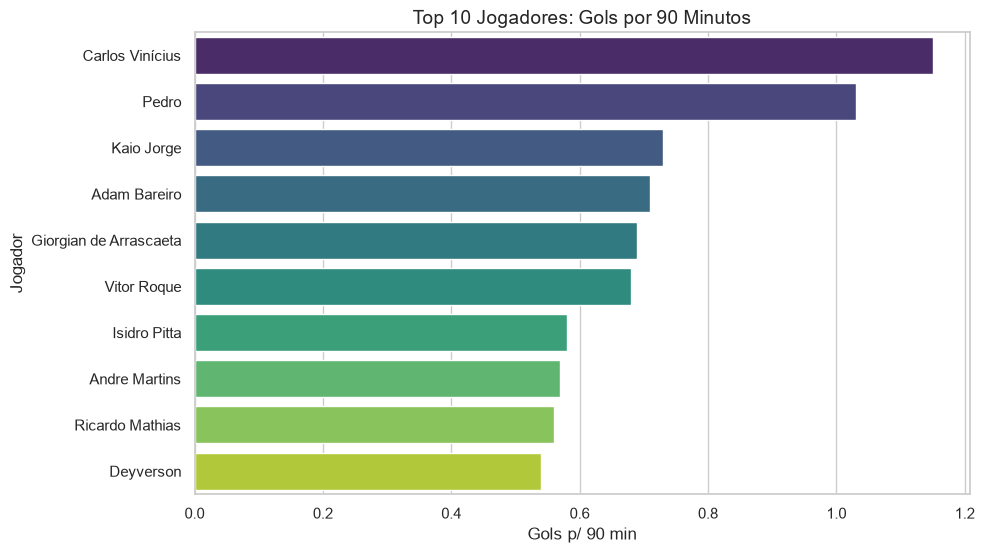

In [7]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_xg.head(10), x=col_xg90, y=col_player, palette="viridis")
plt.title("Top 10 Jogadores: Gols por 90 Minutos", fontsize=14)
plt.xlabel("Gols p/ 90 min", fontsize=12)
plt.ylabel("Jogador", fontsize=12)
plt.show()

### Gráfico 2: Gols vs Assistências (Visão Geral de Playmakers)
Quem participa mais ativamente em gols? (Apenas quem tem minutos consideráveis)

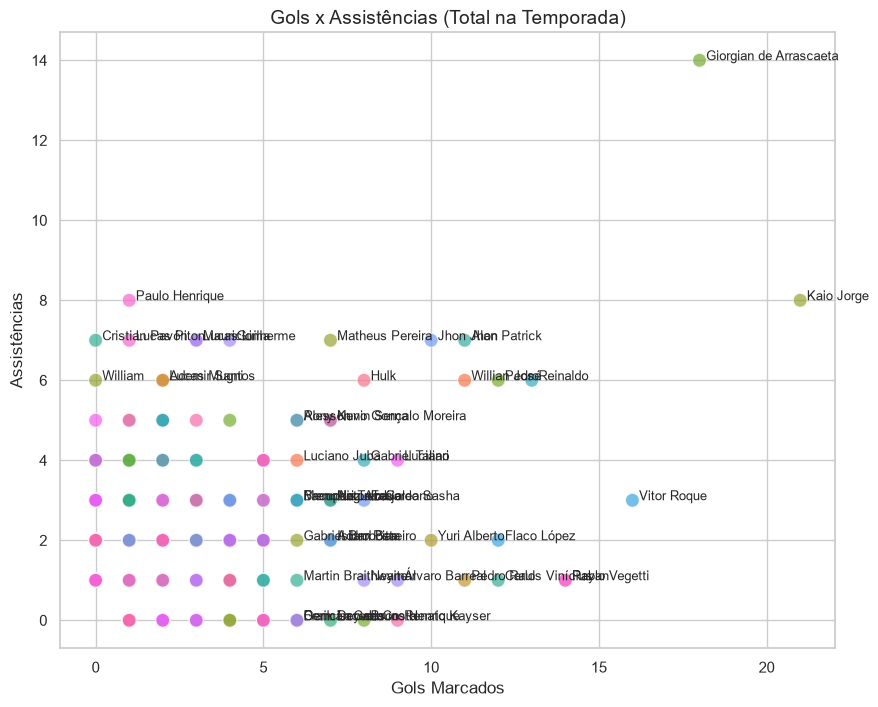

In [8]:
col_ast = ('Performance', 'Ast')
col_gls = ('Performance', 'Gls')

# Filtramos para ver apenas jogadores com pelo menos 1 gol ou 1 assistência
df_playmakers = df_filtered[(df_filtered[col_gls] > 0) | (df_filtered[col_ast] > 0)]

plt.figure(figsize=(10, 8))
sns.scatterplot(data=df_playmakers, x=col_gls, y=col_ast, hue=col_team, s=100, alpha=0.7, legend=False)
plt.title("Gols x Assistências (Total na Temporada)", fontsize=14)
plt.xlabel("Gols Marcados", fontsize=12)
plt.ylabel("Assistências", fontsize=12)

# Adicionar rótulos para os jogadores muito acima da média
for i in range(df_playmakers.shape[0]):
    gls = df_playmakers[col_gls].iloc[i]
    ast = df_playmakers[col_ast].iloc[i]
    if gls > 5 or ast > 5:
        plt.text(gls + 0.2, ast, df_playmakers[col_player].iloc[i], fontsize=9)

plt.show()

### Gráfico 3: Distribuição de Idades na Série A
Como é o perfil de idade dos jogadores atuando ativamente no campeonato?

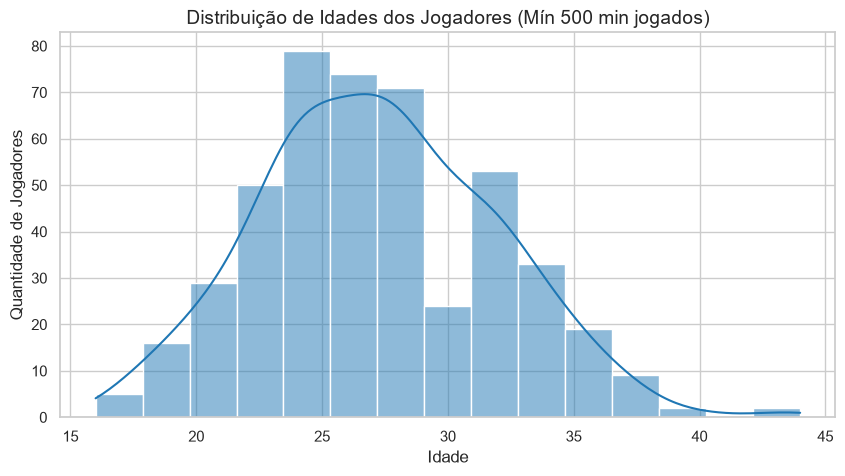

In [9]:
col_age = ('age', '')
# A idade já vem como float/int nesta versão, convertemos diretamente
df_filtered['Idade'] = df_filtered[col_age].astype(float)

plt.figure(figsize=(10, 5))
sns.histplot(data=df_filtered, x='Idade', bins=15, kde=True, color="#1f77b4")
plt.title("Distribuição de Idades dos Jogadores (Mín 500 min jogados)", fontsize=14)
plt.xlabel("Idade", fontsize=12)
plt.ylabel("Quantidade de Jogadores", fontsize=12)
plt.show()

### Gráfico 4: Piores Defesas (Gols Sofridos por Equipe)
Visualizando os dados que calculamos na parte 2.

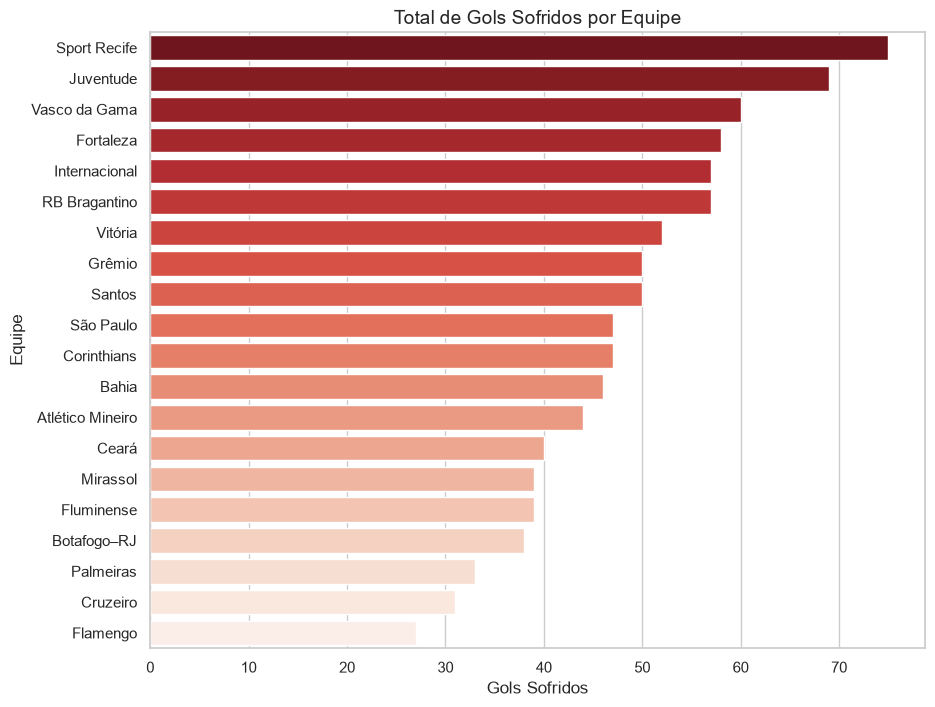

In [10]:
plt.figure(figsize=(10, 8))
sns.barplot(data=df_defense, x='goals_conceded', y='team', palette="Reds_r")
plt.title("Total de Gols Sofridos por Equipe", fontsize=14)
plt.xlabel("Gols Sofridos", fontsize=12)
plt.ylabel("Equipe", fontsize=12)
plt.show()

### Gráfico 5: Relação entre Idade e Tempo de Jogo (Minutos) por Posição
Será que os jogadores mais experientes ou os mais jovens ganham mais minutos em campo no Brasileirão Série A?

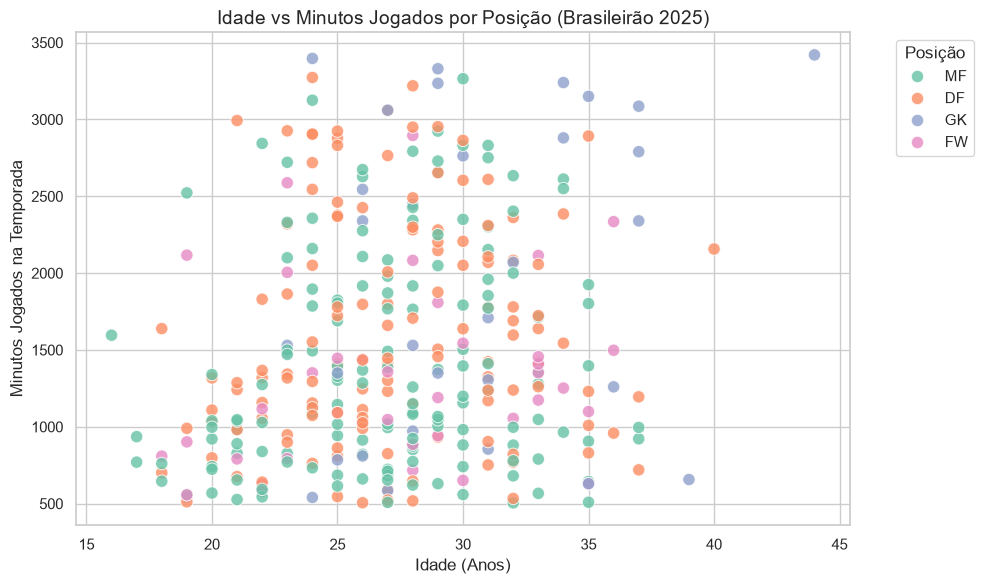

In [11]:
col_age = ('age', '')
col_min = ('Playing Time', 'Min')
col_pos = ('pos', '')

plt.figure(figsize=(10, 6))
df_play_time = df_filtered.dropna(subset=[col_age, col_min, col_pos])
# Filtra posições principais para evitar ruído de transição
df_play_time = df_play_time[df_play_time[col_pos].isin(['DF', 'MF', 'FW', 'GK'])]

sns.scatterplot(x=df_play_time['Idade'], y=df_play_time[col_min], hue=df_play_time[col_pos], alpha=0.8, s=80, palette='Set2')
plt.title("Idade vs Minutos Jogados por Posição (Brasileirão 2025)", fontsize=14)
plt.xlabel("Idade (Anos)", fontsize=12)
plt.ylabel("Minutos Jogados na Temporada", fontsize=12)
plt.legend(title="Posição", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Gráfico 6: Correlação entre Posse de Bola e Gols Marcados (Equipes)
Equipes que mantêm mais a posse de bola tendem a marcar mais gols? Vamos analisar a posse de bola média vs gols marcados.

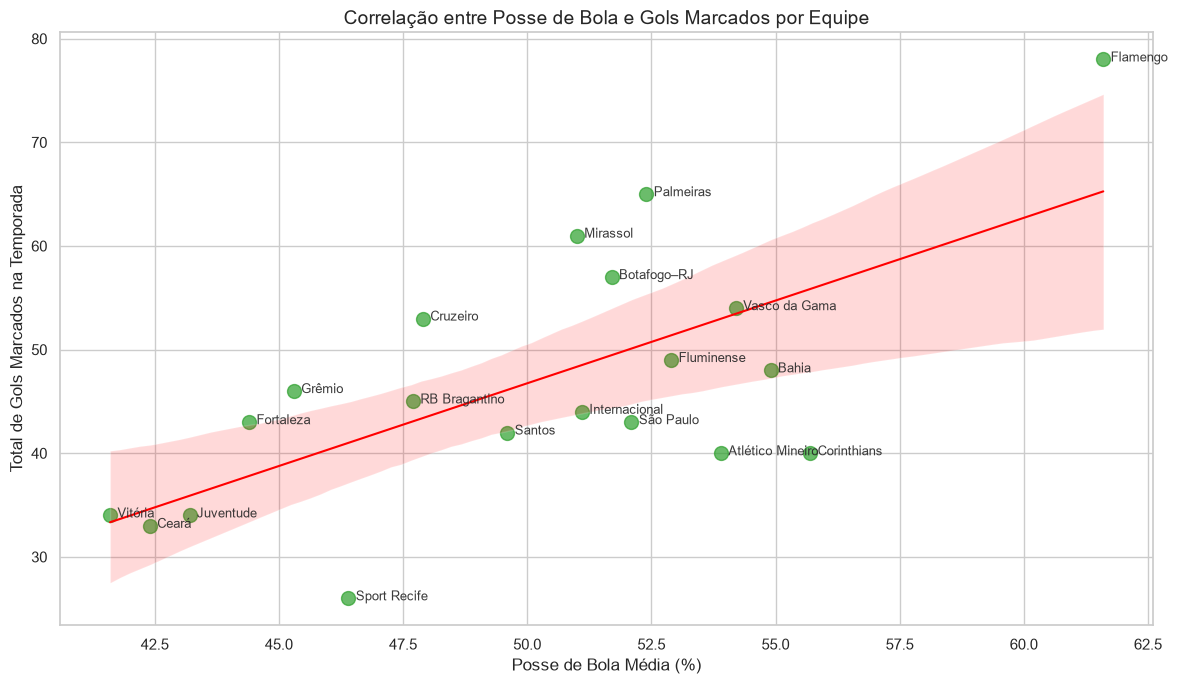

In [12]:
df_teams = pd.read_parquet('../data/parquet/team_stats.parquet').reset_index()
col_poss = ('Poss', '')
col_team_gls = ('Performance', 'Gls')
col_team_name = ('team', '')

plt.figure(figsize=(12, 7))
sns.regplot(x=df_teams[col_poss], y=df_teams[col_team_gls], scatter_kws={'s': 100, 'alpha': 0.7, 'color': '#2ca02c'}, line_kws={'color': 'red', 'linewidth': 1.5})

# Rótulos para cada equipe
for i in range(df_teams.shape[0]):
    plt.text(df_teams[col_poss].iloc[i] + 0.15, df_teams[col_team_gls].iloc[i] - 0.2, df_teams[col_team_name].iloc[i], fontsize=9, alpha=0.9)

plt.title("Correlação entre Posse de Bola e Gols Marcados por Equipe", fontsize=14)
plt.xlabel("Posse de Bola Média (%)", fontsize=12)
plt.ylabel("Total de Gols Marcados na Temporada", fontsize=12)
plt.tight_layout()
plt.show()

### Gráfico 7: Disciplina (Cartões Amarelos vs Cartões Vermelhos por Equipe)
Quais equipes são as mais punidas em termos de cartões amarelos (barras amareladas) e cartões vermelhos (linha vermelha)?

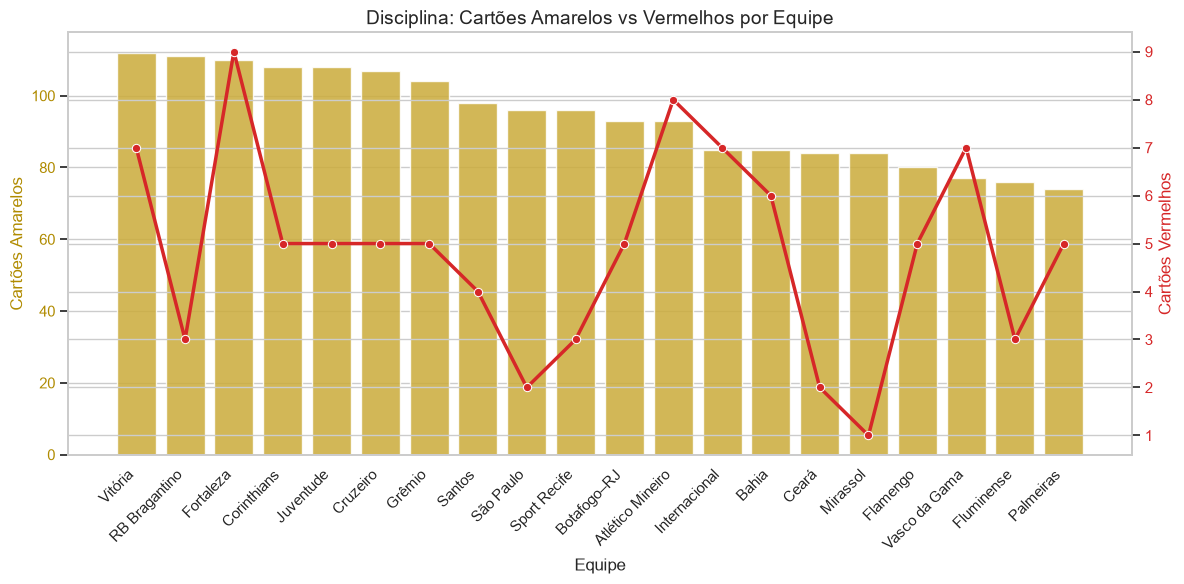

In [13]:
col_team_crd_y = ('Performance', 'CrdY')
col_team_crd_r = ('Performance', 'CrdR')

# Ordenando por cartões amarelos
df_teams_sorted = df_teams.sort_values(by=col_team_crd_y, ascending=False)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Cartões Amarelos (Eixo da esquerda)
color_y = '#e3b822'
sns.barplot(x=df_teams_sorted[col_team_name], y=df_teams_sorted[col_team_crd_y], ax=ax1, color=color_y, alpha=0.85)
ax1.set_title("Disciplina: Cartões Amarelos vs Vermelhos por Equipe", fontsize=14)
ax1.set_xlabel("Equipe", fontsize=12)
ax1.set_ylabel("Cartões Amarelos", fontsize=12, color='#b08b00')
ax1.tick_params(axis='y', labelcolor='#b08b00')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')

# Cartões Vermelhos (Eixo da direita)
ax2 = ax1.twinx()
color_r = '#d62728'
sns.lineplot(x=df_teams_sorted[col_team_name], y=df_teams_sorted[col_team_crd_r], ax=ax2, color=color_r, marker='o', linewidth=2.5, sort=False)
ax2.set_ylabel("Cartões Vermelhos", fontsize=12, color=color_r)
ax2.tick_params(axis='y', labelcolor=color_r)

plt.tight_layout()
plt.show()